# 66 — LSEG Gemma/FinBERT backward-replication gate

**Question.** Can the unchanged Notebook 36 Gemma-timing/FinBERT-ranking strategy be tested on the earlier, non-overlapping 2024-01-01 to 2025-10-26 LSEG interval without reopening methodology after seeing returns?

**Current estimand.** This notebook has none in return space. It audits acquisition checkpoints, exact scorer-population coverage, complete cross-sectional dates, request density, storage capacity, and the predeclared Gemma measurement-stability design. Prices, returns, positions, and portfolio outcomes are deliberately absent.

**Scheduling amendment.** Day one collected company-major. Future resumptions collect date-major, reusing the same checkpoints, so progress converges toward a complete 33-company date prefix. The final frozen population is unchanged.

**Claim boundary.** The dashboard is operational evidence only. Its completion and storage projections are planning estimates, not signal or performance results. The all-history matrix combines checkpoint metadata from contiguous same-33 collections only; collection labels preserve acquisition boundaries while fill and hatching show scoring state, and neither licenses the regimes to be pooled for inference. A later successful replay would be historical external-time corroboration, not prospective or deployment validation. The binding contract is `frozen_specs/lseg_gemma_finbert_hybrid_backward_v1.json`; dated amendments record the 10,000-request operational cap, date-major traversal, and authorised incremental scorer preprocessing.

In [1]:
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle
import pandas as pd
from IPython.display import display

SEED = 20260806
ROOT = Path.cwd().resolve()
if not (ROOT / 'final_experiments').is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.backward_validation import audit_backward_collection, audit_lseg_collection_coverage
from final_experiments.lib.plots import CATEGORICAL, INK, STATUS, annotate_source, apply_house_style
from sentiment_benchmark.artifact_io import sha256_text
from sentiment_benchmark.headline_value import normalize_headline

SPEC_PATH = ROOT / 'final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_backward_v1.json'
OPERATIONAL_AMENDMENT_PATH = ROOT / 'final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_backward_operational_amendment_20260806.json'
ORDER_AMENDMENT_PATH = ROOT / 'final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_backward_collection_order_amendment_20260806.json'
BACKWARD_SNAPSHOT_ROOT = ROOT / 'Data/collections/lseg_us_sector_33_backward_20240101_20251026_headlines/derived/incremental_finbert/snapshot_20260810_second_account_quota_stop'
BACKWARD_SNAPSHOT_MANIFEST_PATH = BACKWARD_SNAPSHOT_ROOT / 'manifest.json'
BACKWARD_FINBERT_COMPLETION_PATH = BACKWARD_SNAPSHOT_ROOT / 'finbert_verified_completion.json'
BACKWARD_GEMMA_SCORE_PATHS = [
    ROOT / 'Data/collections/lseg_us_sector_33_backward_20240101_20251026_headlines/derived/incremental_gemma/snapshot_20260809_quota_stop/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv',
    ROOT / 'Data/collections/lseg_us_sector_33_backward_20240101_20251026_headlines/derived/incremental_gemma/snapshot_20260810_second_account_quota_stop/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1_delta.csv',
]
BACKWARD_GEMMA_MANIFEST_PATHS = [
    path.with_suffix(path.suffix + '.manifest.json') for path in BACKWARD_GEMMA_SCORE_PATHS
]
FIGURE_DIR = ROOT / 'final_experiments/outputs/figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RECENT_FINBERT_MANIFEST_PATH = ROOT / 'Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_finbert4556_cacheonly_20260803.csv.manifest.json'
RECENT_GEMMA_MANIFEST_PATH = ROOT / 'Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv.manifest.json'
COVERAGE_COLLECTIONS = [
    ('backward extension', ROOT / 'configs/lseg_us_sector_33_backward_20240101_20251026_headlines.toml'),
    ('existing recent 2m', ROOT / 'configs/lseg_us_sector_33_back2m_headlines.toml'),
    ('existing recent 6m', ROOT / 'configs/lseg_us_sector_33_6m.toml'),
    ('prospective extension', ROOT / 'configs/lseg_us_sector_33_prospective_20260626_20260806_headlines.toml'),
]
OPERATIONAL_DAILY_REQUEST_BUDGET = 10_000
for required_path in (
    SPEC_PATH,
    OPERATIONAL_AMENDMENT_PATH,
    ORDER_AMENDMENT_PATH,
    BACKWARD_SNAPSHOT_MANIFEST_PATH,
    BACKWARD_FINBERT_COMPLETION_PATH,
    *BACKWARD_GEMMA_SCORE_PATHS,
    *BACKWARD_GEMMA_MANIFEST_PATHS,
    RECENT_FINBERT_MANIFEST_PATH,
    RECENT_GEMMA_MANIFEST_PATH,
    *(path for _label, path in COVERAGE_COLLECTIONS),
):
    assert required_path.is_file(), required_path

apply_house_style()
plt.rcParams['axes.titleweight'] = 'normal'
pd.set_option('display.max_colwidth', 110)
ROOT

PosixPath('/Users/peterprendergast/Documents/Sentiment_Dissertation')

## Frozen stage order

1. Complete and hash the same-33 headline collection. The source config retains its 9,500-request identity default; the dated operational amendment permits up to 10,000 requests on a normal reset day.
2. Resume date-major: finish every missing company for the earliest date before advancing. Existing AAPL/MSFT/NVDA checkpoints remain valid and are never fetched again.
3. Normalize and deduplicate headlines without market data.
4. Re-score the frozen Gemma drift sample and require every stability threshold.
5. Score the complete new population with the unchanged Gemma and FinBERT contracts.
6. Build firm-open signals without prices and require 120 complete sessions, 60 active sessions, and 20 active sessions per half.
7. Only then may a separate one-shot return replay load prices.

A partial batch can answer only whether acquisition is healthy, how much complete cross-sectional history exists, and whether quota/storage planning remains feasible. It cannot answer whether the strategy works.

In [2]:
collection_audit = audit_backward_collection(
    ROOT,
    SPEC_PATH,
    daily_request_budget=OPERATIONAL_DAILY_REQUEST_BUDGET,
)
progress = collection_audit.summary.iloc[0]
date_progress = collection_audit.date_progress.copy()
company_date_completion = collection_audit.company_date_completion.copy()
projection = collection_audit.projection.iloc[0]
symbol_order = company_date_completion['symbol'].drop_duplicates().tolist()
coverage_audit = audit_lseg_collection_coverage(
    ROOT,
    COVERAGE_COLLECTIONS,
    expected_symbols=symbol_order,
)
combined_company_date_completion = coverage_audit.company_date_completion.copy()

progress_columns = [
    'status', 'companies', 'windows_per_company', 'completed_windows', 'expected_windows',
    'window_completion_pct', 'headline_pages', 'complete_dates', 'complete_date_prefix',
    'partial_dates', 'untouched_dates', 'frontier_date', 'frontier_companies_completed',
    'pagination_anomalies',
]
display(collection_audit.summary[progress_columns])

projection_metrics = pd.DataFrame(
    [
        ('projection basis', projection['projection_basis']),
        ('daily request budget', f"{int(projection['daily_request_budget']):,}"),
        ('requests / completed company-window', f"{projection['observed_requests_per_completed_company_window']:.2f}"),
        (
            'requests / complete 33-company date',
            'not available yet'
            if pd.isna(projection['observed_requests_per_complete_date'])
            else f"{projection['observed_requests_per_complete_date']:.2f}",
        ),
        ('minimum remaining requests', f"{int(projection['minimum_remaining_requests']):,}"),
        ('estimated remaining requests', f"{int(projection['estimated_remaining_requests']):,}"),
        ('estimated remaining full-quota days', f"{int(projection['estimated_remaining_quota_days'])}"),
        ('current raw collection', f"{projection['current_raw_storage_gib']:.2f} GiB"),
        ('projected additional storage', f"{projection['projected_additional_storage_gib']:.2f} GiB"),
        ('free disk now', f"{projection['free_disk_gib']:.2f} GiB"),
        ('projected disk headroom', f"{projection['projected_free_after_completion_gib']:.2f} GiB"),
    ],
    columns=['metric', 'value'],
)
display(projection_metrics)
display(collection_audit.gate_table)
display(
    coverage_audit.summary[
        [
            'collection_label', 'manifest_status', 'start', 'end', 'dates',
            'completed_windows', 'expected_windows', 'window_completion_pct',
            'headline_pages', 'pagination_anomalies', 'unsafe_pagination_reasons',
        ]
    ]
)
assert coverage_audit.summary['unsafe_pagination_reasons'].eq('').all()
collection_audit.collection_gate_pass

,status,companies,windows_per_company,completed_windows,expected_windows,window_completion_pct,headline_pages,complete_dates,complete_date_prefix,partial_dates,untouched_dates,frontier_date,frontier_companies_completed,pagination_anomalies
0,completed,33,664,21912,21912,100.0,53904,664,664,0,0,None,None,1


,metric,value
0,projection basis,mean page requests across completed 33-company dates
1,daily request budget,"10,000"
2,requests / completed company-window,2.46
3,requests / complete 33-company date,81.18
4,minimum remaining requests,0
5,estimated remaining requests,0
6,estimated remaining full-quota days,0
7,current raw collection,13.28 GiB
8,projected additional storage,0.00 GiB
9,free disk now,20.52 GiB


,gate,passed
0,manifest_completed,True
1,all_company_windows_completed,True
2,headline_file_hash_matches,True
3,empty_story_file_hash_matches,True
4,no_unsafe_pagination_anomalies,True
5,headline_only_zero_stories,True
6,collection_ready_for_drift_audit,True


,collection_label,manifest_status,start,end,dates,completed_windows,expected_windows,window_completion_pct,headline_pages,pagination_anomalies,unsafe_pagination_reasons
0,backward extension,completed,2024-01-01T00:00:00Z,2025-10-26T00:00:00Z,664,21912,21912,100.0,53904,1,
1,existing recent 2m,completed,2025-10-26T00:00:00Z,2025-12-26T00:00:00Z,61,2013,2013,100.0,6083,2,
2,existing recent 6m,completed,2025-12-26T00:00:00Z,2026-06-26T00:00:00Z,182,6006,6006,100.0,16621,3,
3,prospective extension,completed,2026-06-26T00:00:00Z,2026-08-06T00:00:00Z,41,1353,1353,100.0,3772,0,


True

In [3]:
# Reconstruct the exact backward company-date set frozen for scoring. File mtimes are
# used only to propose the set; the frozen count and SHA-256 must then match exactly.
backward_snapshot_manifest = json.loads(BACKWARD_SNAPSHOT_MANIFEST_PATH.read_text(encoding='utf-8'))
backward_finbert_completion = json.loads(BACKWARD_FINBERT_COMPLETION_PATH.read_text(encoding='utf-8'))
backward_gemma_manifests = [
    json.loads(path.read_text(encoding='utf-8')) for path in BACKWARD_GEMMA_MANIFEST_PATHS
]
latest_backward_gemma_manifest = backward_gemma_manifests[-1]
recent_finbert_manifest = json.loads(RECENT_FINBERT_MANIFEST_PATH.read_text(encoding='utf-8'))
recent_gemma_manifest = json.loads(RECENT_GEMMA_MANIFEST_PATH.read_text(encoding='utf-8'))
snapshot_meta = backward_snapshot_manifest['snapshot']
snapshot_cutoff = pd.Timestamp(snapshot_meta['created_at']).timestamp()
snapshot_pages_dir = Path(snapshot_meta['source_manifest_path']).parent / 'headline_pages'
assert snapshot_pages_dir.is_dir(), snapshot_pages_dir

backward_snapshot_pairs = set()
for page_path in snapshot_pages_dir.glob('*.json'):
    if page_path.stat().st_mtime > snapshot_cutoff:
        continue
    payload = json.loads(page_path.read_text(encoding='utf-8'))
    terminal = not str(payload.get('cursor_out') or '').strip() or bool(
        str(payload.get('pagination_terminal_reason') or '').strip()
    )
    if terminal:
        backward_snapshot_pairs.add((str(payload['symbol']).upper(), int(payload['window_index'])))
ordered_snapshot_pairs = sorted(backward_snapshot_pairs, key=lambda item: (item[1], item[0]))
snapshot_pairs_sha256 = sha256_text('\n'.join(f'{symbol}|{window}' for symbol, window in ordered_snapshot_pairs))
assert len(backward_snapshot_pairs) == int(snapshot_meta['completed_company_dates'])
assert snapshot_pairs_sha256 == snapshot_meta['completed_company_dates_sha256']
current_backward_pairs = set(
    company_date_completion.loc[company_date_completion['complete'], ['symbol', 'window_index']].itertuples(
        index=False, name=None
    )
)
assert backward_snapshot_pairs <= current_backward_pairs

# Identify the 17 unresolved Gemma hashes and the exact company-days they affect.
gemma_success_hashes = set()
for score_path in BACKWARD_GEMMA_SCORE_PATHS:
    with score_path.open(encoding='utf-8', newline='') as handle:
        for row in csv.DictReader(handle):
            if row.get('status') == 'success':
                gemma_success_hashes.add(str(row['headline_sha256']))
assert len(gemma_success_hashes) == int(latest_backward_gemma_manifest['counts']['successful_after_run'])

unresolved_gemma = {}
with (BACKWARD_SNAPSHOT_ROOT / 'headlines.jsonl').open(encoding='utf-8') as handle:
    for line in handle:
        row = json.loads(line)
        normalized = normalize_headline(str(row.get('headline') or ''))
        if not normalized:
            continue
        headline_hash = sha256_text(normalized)
        if headline_hash in gemma_success_hashes:
            continue
        timestamp = str(row.get('version_created') or row.get('first_created') or '')
        item = unresolved_gemma.setdefault(headline_hash, {'symbols': set(), 'timestamp': timestamp})
        item['symbols'].update(str(symbol) for symbol in (row.get('matched_symbols') or ()))
        if timestamp and (not item['timestamp'] or timestamp < item['timestamp']):
            item['timestamp'] = timestamp
assert len(unresolved_gemma) == int(latest_backward_gemma_manifest['counts']['remaining_after_run'])
unresolved_company_dates = {
    (symbol, f"{details['timestamp'][:10]}T00:00:00Z")
    for details in unresolved_gemma.values()
    for symbol in details['symbols']
}

assert backward_finbert_completion['status'] == 'completed'
assert int(backward_finbert_completion['finbert_successes']) == int(snapshot_meta['unique_scorable_headlines'])
assert recent_finbert_manifest['status'] == 'completed'
assert recent_gemma_manifest['status'] == 'completed'
assert int(recent_finbert_manifest['summary']['unique_headlines']) == int(recent_gemma_manifest['counts']['population'])
assert int(recent_gemma_manifest['counts']['remaining_after_run']) == 0

combined_company_date_completion['in_scoring_snapshot'] = False
backward_mask = combined_company_date_completion['collection_label'].eq('backward extension')
recent_mask = combined_company_date_completion['collection_label'].isin(['existing recent 2m', 'existing recent 6m'])
combined_company_date_completion.loc[backward_mask, 'in_scoring_snapshot'] = [
    bool(complete) and (symbol, int(window_index)) in backward_snapshot_pairs
    for symbol, window_index, complete in combined_company_date_completion.loc[
        backward_mask, ['symbol', 'window_index', 'complete']
    ].itertuples(index=False, name=None)
]
combined_company_date_completion.loc[recent_mask, 'in_scoring_snapshot'] = combined_company_date_completion.loc[
    recent_mask, 'complete'
]
combined_company_date_completion['score_state'] = 'not_downloaded'
combined_company_date_completion.loc[combined_company_date_completion['complete'], 'score_state'] = 'downloaded_unscored'
combined_company_date_completion.loc[combined_company_date_completion['in_scoring_snapshot'], 'score_state'] = 'fully_scored'
partial_mask = backward_mask & combined_company_date_completion.apply(
    lambda row: (row['symbol'], row['window_start']) in unresolved_company_dates, axis=1
)
combined_company_date_completion.loc[partial_mask, 'score_state'] = 'partially_scored'
assert int(partial_mask.sum()) == len(unresolved_company_dates)

score_pipeline_summary = pd.DataFrame(
    [
        {
            'scope': 'existing recent 8m',
            'unique headlines': int(recent_gemma_manifest['counts']['population']),
            'FinBERT successes': int(recent_finbert_manifest['summary']['unique_headlines']),
            'Gemma successes': int(recent_gemma_manifest['counts']['successful_after_run']),
            'Gemma unresolved': int(recent_gemma_manifest['counts']['remaining_after_run']),
        },
        {
            'scope': BACKWARD_SNAPSHOT_ROOT.name,
            'unique headlines': int(snapshot_meta['unique_scorable_headlines']),
            'FinBERT successes': int(backward_finbert_completion['finbert_successes']),
            'Gemma successes': int(latest_backward_gemma_manifest['counts']['successful_after_run']),
            'Gemma unresolved': int(latest_backward_gemma_manifest['counts']['remaining_after_run']),
        },
    ]
)
display(score_pipeline_summary)
combined_company_date_completion['score_state'].value_counts().rename_axis('company-day state').to_frame('count')

,scope,unique headlines,FinBERT successes,Gemma successes,Gemma unresolved
0,existing recent 8m,888155,888155,888155,0
1,snapshot_20260810_second_account_quota_stop,884863,884863,884846,17


,count
company-day state,
fully_scored,25969
downloaded_unscored,5298
partially_scored,17


## Date-major acquisition dashboard

The company-by-date matrix has one cell for every frozen company-day from 2024-01-01 through 2026-08-06. Grey is absent or incomplete, amber hatching is downloaded but outside the latest score snapshot, orange cross-hatching is a score-snapshot company-day touched by one of the 17 unresolved Gemma hashes, and solid blue is fully covered by both FinBERT and Gemma. The backward snapshot membership is reconstructed from checkpoint creation times and must reproduce its frozen company-date count and SHA-256 exactly; otherwise execution stops. Collection boundaries preserve acquisition provenance and still do not permit the source regimes to be pooled for inference.

The following coverage/request panels remain specific to the backward arm: they distinguish a **complete date** (all 33 company windows terminal) from a merely touched date. The frontier is the first date after the contiguous complete prefix; it is absent once the collection is complete. Page checkpoints equal headline-page API requests, so the request panel shows the quota load by date. Licensed text stays local; it is read only to hash-reconcile the 17 unresolved Gemma items and is never displayed.

The completion projection uses mean page density across complete 33-company dates. It is a planning estimate that updates with every resumed collection batch, not a performance result.

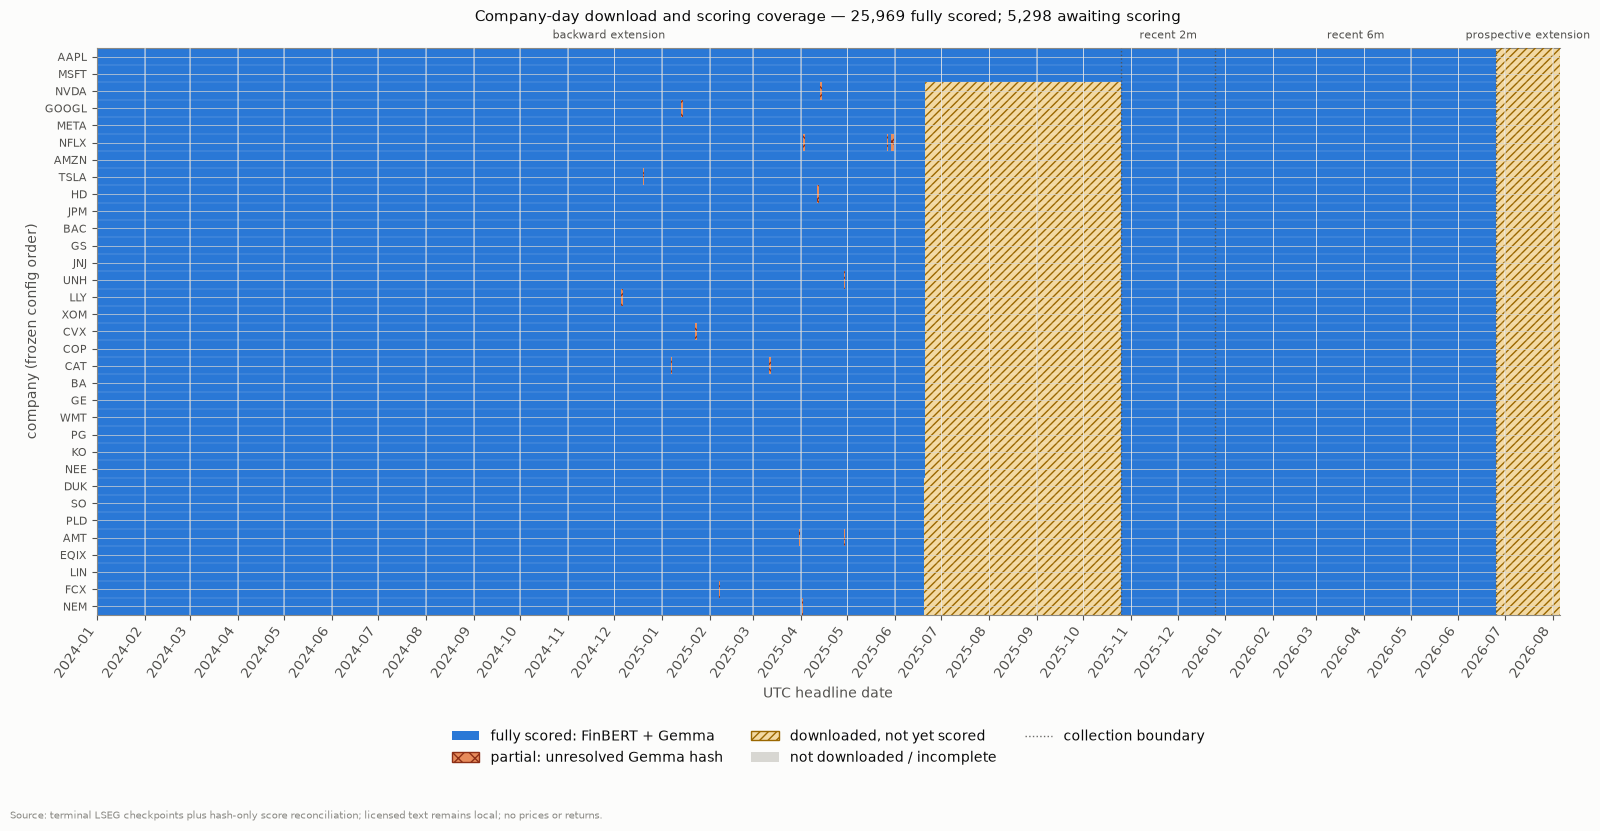

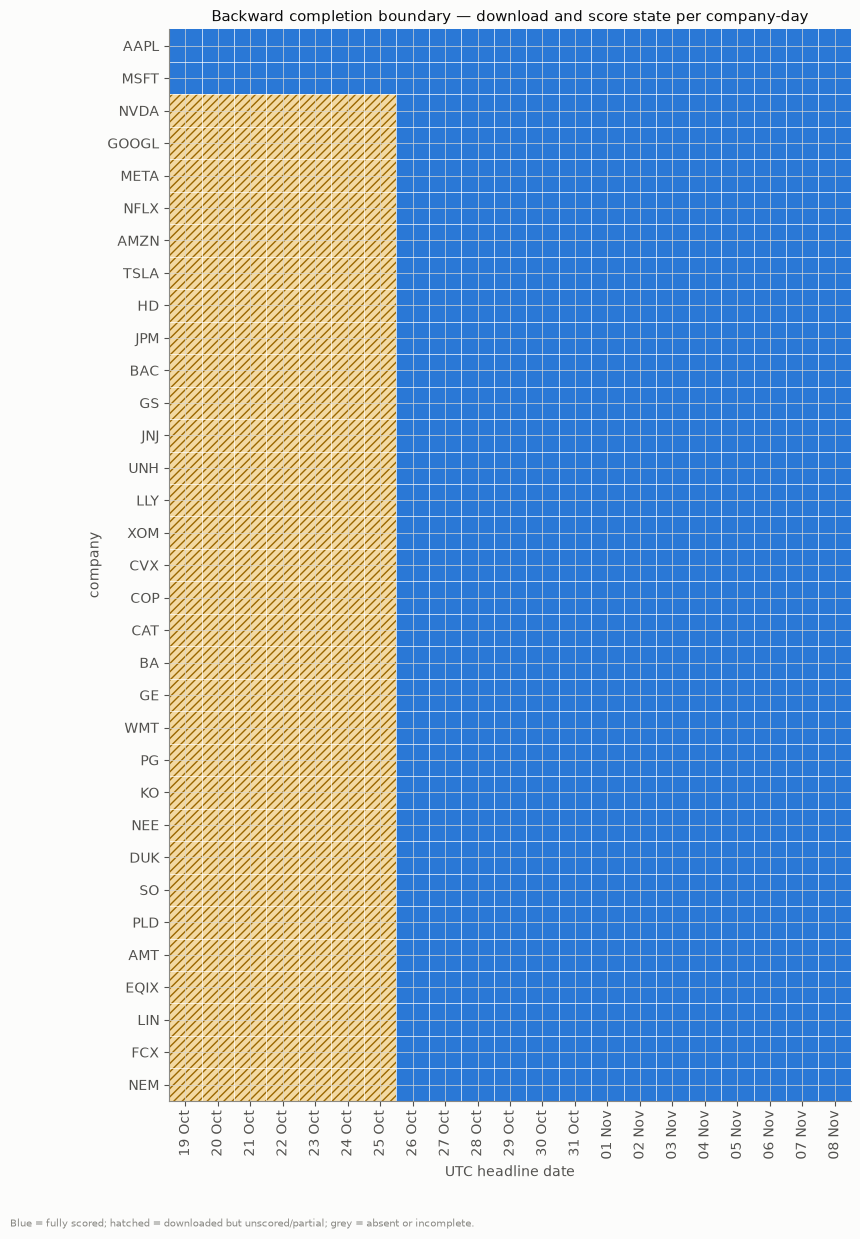

{'combined_matrix_shape': (33, 948),
 'all_downloaded_company_days': 31284,
 'fully_scored_company_days': 25969,
 'partially_scored_company_days': 17,
 'downloaded_unscored_company_days': 5298,
 'not_downloaded_company_days': 0,
 'backward_company_days': 21912,
 'already_existing_company_days': 9372,
 'coverage_start': '2024-01-01T00:00:00Z',
 'coverage_end_exclusive': '2026-08-06T00:00:00Z',
 'backward_frontier_date': None,
 'backward_frontier_companies_completed': None,
 'company_date_figure': '/Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/figures/66_lseg_company_date_download_scoring_coverage.png',
 'backward_detail_figure': '/Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/figures/66_lseg_backward_completion_score_detail.png'}

In [4]:
coverage_dates = (
    combined_company_date_completion[['window_start', 'collection_label']]
    .drop_duplicates()
    .sort_values('window_start')
    .reset_index(drop=True)
)
coverage_dates['date'] = pd.to_datetime(coverage_dates['window_start'], utc=True)
score_state_value = {
    'not_downloaded': 0,
    'downloaded_unscored': 1,
    'partially_scored': 2,
    'fully_scored': 3,
}
combined_company_date_completion['score_state_value'] = combined_company_date_completion['score_state'].map(
    score_state_value
)
coverage_matrix = (
    combined_company_date_completion.pivot(index='symbol', columns='window_start', values='complete')
    .reindex(index=symbol_order, columns=coverage_dates['window_start'])
    .astype(bool)
)
score_state_values = (
    combined_company_date_completion.pivot(index='symbol', columns='window_start', values='score_state_value')
    .reindex(index=symbol_order, columns=coverage_dates['window_start'])
    .astype(int)
)
expected_combined_windows = int(coverage_audit.summary['expected_windows'].sum())
completed_combined_windows = int(coverage_audit.summary['completed_windows'].sum())
backward_completed_windows = int(
    coverage_audit.summary.loc[
        coverage_audit.summary['collection_label'].eq('backward extension'),
        'completed_windows',
    ].iloc[0]
)
existing_completed_windows = completed_combined_windows - backward_completed_windows
assert coverage_matrix.shape == (int(progress['companies']), int(coverage_audit.summary['dates'].sum()))
assert coverage_matrix.shape == score_state_values.shape
assert int(coverage_matrix.to_numpy().sum()) == completed_combined_windows
assert int((score_state_values.to_numpy() > 0).sum()) == completed_combined_windows
assert backward_completed_windows == int(progress['completed_windows'])
assert coverage_audit.summary.loc[
    ~coverage_audit.summary['collection_label'].eq('backward extension'),
    'all_windows_completed',
].all()

fully_scored_company_days = int((score_state_values.to_numpy() == 3).sum())
partially_scored_company_days = int((score_state_values.to_numpy() == 2).sum())
downloaded_unscored_company_days = int((score_state_values.to_numpy() == 1).sum())
not_downloaded_company_days = int((score_state_values.to_numpy() == 0).sum())
assert fully_scored_company_days + partially_scored_company_days + downloaded_unscored_company_days == completed_combined_windows

score_cmap = ListedColormap([INK['grid'], '#F3D9A2', '#E78B5B', CATEGORICAL[0]])
frontier_position = int(progress['complete_date_prefix'])
frontier_date_value = progress['frontier_date']
month_positions = coverage_dates.index[coverage_dates['date'].dt.day.eq(1)].tolist()
month_labels = coverage_dates.loc[month_positions, 'date'].dt.strftime('%Y-%m').tolist()
collection_boundary_positions = coverage_dates.index[
    coverage_dates['collection_label'].ne(coverage_dates['collection_label'].shift())
].tolist()[1:]

def add_hatched_runs(ax, mask, *, hatch, edgecolor):
    """Overlay contiguous true-cell runs without drawing thousands of patches."""
    for row_index, flags in enumerate(mask):
        start = None
        for column_index, flag in enumerate([*flags, False]):
            if flag and start is None:
                start = column_index
            elif not flag and start is not None:
                ax.add_patch(
                    Rectangle(
                        (start - 0.5, row_index - 0.5),
                        column_index - start,
                        1,
                        facecolor='none',
                        edgecolor=edgecolor,
                        hatch=hatch,
                        linewidth=0.0,
                    )
                )
                start = None

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(
    score_state_values.to_numpy(dtype=int),
    aspect='auto',
    interpolation='nearest',
    cmap=score_cmap,
    vmin=0,
    vmax=3,
)
add_hatched_runs(
    ax,
    score_state_values.to_numpy(dtype=int) == 1,
    hatch='////',
    edgecolor='#9A6700',
)
add_hatched_runs(
    ax,
    score_state_values.to_numpy(dtype=int) == 2,
    hatch='xx',
    edgecolor='#8C2F16',
)
ax.set_xticks(month_positions, labels=month_labels, rotation=55, ha='right')
ax.set_yticks(range(len(symbol_order)), labels=symbol_order)
ax.tick_params(axis='y', labelsize=8)
collection_segments = {
    label: (int(frame.index.min()), int(frame.index.max()))
    for label, frame in coverage_dates.groupby('collection_label', sort=False)
}
top_axis = ax.secondary_xaxis('top')
top_axis.set_xticks(
    [(start + stop) / 2 for start, stop in collection_segments.values()],
    labels=[label.replace('existing ', '') for label in collection_segments],
)
top_axis.tick_params(axis='x', length=0, labelsize=8, pad=5)
for month_position in month_positions:
    ax.axvline(month_position - 0.5, color='white', lw=0.45, alpha=0.65)
ax.set_yticks([row - 0.5 for row in range(1, len(symbol_order))], minor=True)
ax.grid(which='minor', axis='y', color='white', lw=0.35, alpha=0.35)
ax.tick_params(which='minor', left=False)
legend_handles = [
    Patch(facecolor=CATEGORICAL[0], label='fully scored: FinBERT + Gemma'),
    Patch(facecolor='#E78B5B', edgecolor='#8C2F16', hatch='xx', label='partial: unresolved Gemma hash'),
    Patch(facecolor='#F3D9A2', edgecolor='#9A6700', hatch='////', label='downloaded, not yet scored'),
    Patch(facecolor=INK['grid'], label='not downloaded / incomplete'),
]
boundary_handle = None
for boundary_position in collection_boundary_positions:
    handle = ax.axvline(
        boundary_position - 0.5,
        color=INK['secondary'],
        lw=1.0,
        ls=':',
        alpha=0.85,
        label='collection boundary',
    )
    boundary_handle = boundary_handle or handle
if boundary_handle is not None:
    legend_handles.append(boundary_handle)
if frontier_date_value is not None and frontier_position < coverage_matrix.shape[1]:
    frontier_handle = ax.axvline(
        frontier_position - 0.5,
        color=STATUS['warning'],
        lw=1.5,
        ls='--',
        label='complete-prefix frontier',
    )
    legend_handles.append(frontier_handle)
ax.set_xlabel('UTC headline date')
ax.set_ylabel('company (frozen config order)')
ax.set_title(
    f"Company-day download and scoring coverage — {fully_scored_company_days:,} fully scored; "
    f"{downloaded_unscored_company_days:,} awaiting scoring"
)
ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3)
annotate_source(
    fig,
    'Source: terminal LSEG checkpoints plus hash-only score reconciliation; licensed text remains local; no prices or returns.',
)
fig.tight_layout()
COMPANY_DATE_FIGURE_PATH = FIGURE_DIR / '66_lseg_company_date_download_scoring_coverage.png'
fig.savefig(COMPANY_DATE_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()

zoom_start = max(frontier_position - 7, 0)
zoom_stop = min(frontier_position + 14, coverage_matrix.shape[1])
zoom_matrix = score_state_values.iloc[:, zoom_start:zoom_stop]
zoom_dates = coverage_dates.iloc[zoom_start:zoom_stop]['date'].dt.strftime('%d %b').tolist()
fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(
    zoom_matrix.to_numpy(dtype=int),
    aspect='equal',
    interpolation='none',
    cmap=score_cmap,
    vmin=0,
    vmax=3,
)
add_hatched_runs(ax, zoom_matrix.to_numpy(dtype=int) == 1, hatch='////', edgecolor='#9A6700')
add_hatched_runs(ax, zoom_matrix.to_numpy(dtype=int) == 2, hatch='xx', edgecolor='#8C2F16')
ax.set_xticks(range(len(zoom_dates)), labels=zoom_dates, rotation=90)
ax.set_yticks(range(len(symbol_order)), labels=symbol_order)
ax.set_xticks([column - 0.5 for column in range(1, len(zoom_dates))], minor=True)
ax.set_yticks([row - 0.5 for row in range(1, len(symbol_order))], minor=True)
ax.grid(which='minor', color='white', lw=0.55, alpha=0.9)
ax.tick_params(which='minor', bottom=False, left=False)
if frontier_date_value is not None and zoom_start <= frontier_position < zoom_stop:
    ax.axvline(frontier_position - zoom_start - 0.5, color=STATUS['warning'], lw=1.6, ls='--')
ax.set_xlabel('UTC headline date')
ax.set_ylabel('company')
ax.set_title(
    'Backward frontier detail — download and score state per company-day'
    if frontier_date_value is not None
    else 'Backward completion boundary — download and score state per company-day'
)
annotate_source(fig, 'Blue = fully scored; hatched = downloaded but unscored/partial; grey = absent or incomplete.')
fig.tight_layout()
BACKWARD_DETAIL_FIGURE_PATH = FIGURE_DIR / '66_lseg_backward_completion_score_detail.png'
fig.savefig(BACKWARD_DETAIL_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()

{
    'combined_matrix_shape': coverage_matrix.shape,
    'all_downloaded_company_days': completed_combined_windows,
    'fully_scored_company_days': fully_scored_company_days,
    'partially_scored_company_days': partially_scored_company_days,
    'downloaded_unscored_company_days': downloaded_unscored_company_days,
    'not_downloaded_company_days': not_downloaded_company_days,
    'backward_company_days': backward_completed_windows,
    'already_existing_company_days': existing_completed_windows,
    'coverage_start': coverage_dates['window_start'].iloc[0],
    'coverage_end_exclusive': coverage_audit.summary['end'].iloc[-1],
    'backward_frontier_date': progress['frontier_date'],
    'backward_frontier_companies_completed': (
        None
        if pd.isna(progress['frontier_companies_completed'])
        else int(progress['frontier_companies_completed'])
    ),
    'company_date_figure': str(COMPANY_DATE_FIGURE_PATH),
    'backward_detail_figure': str(BACKWARD_DETAIL_FIGURE_PATH),
}

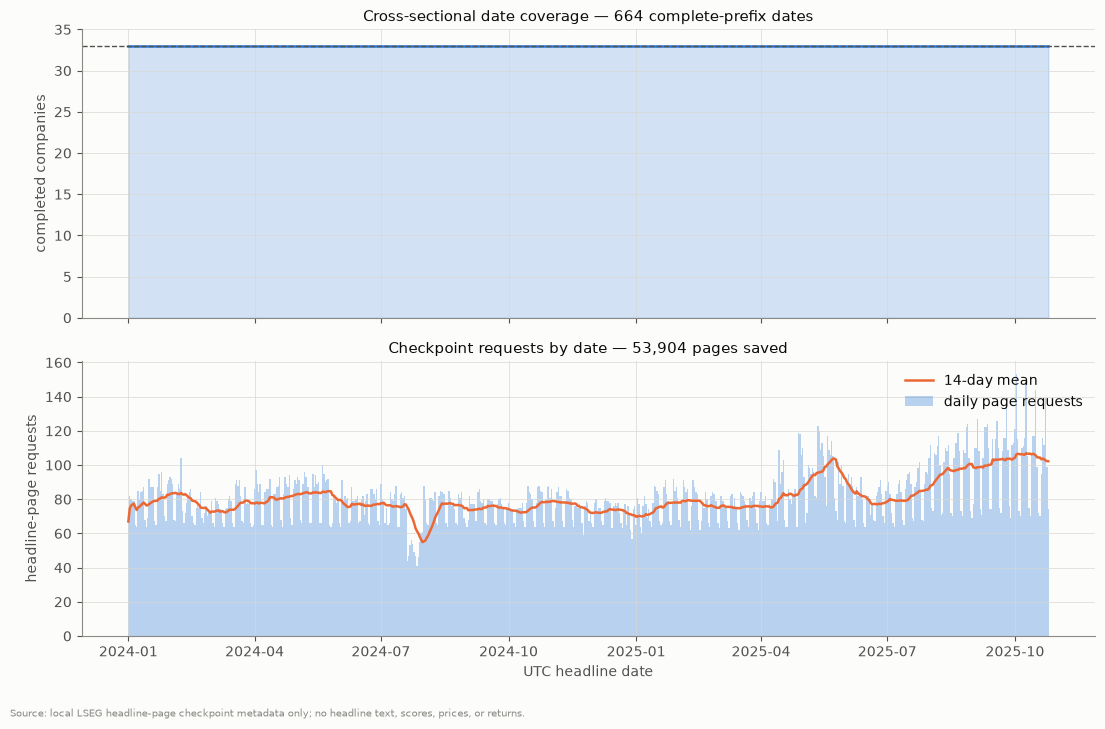

In [5]:
date_progress['date'] = pd.to_datetime(date_progress['window_start'], utc=True)
frontier_position = int(progress['complete_date_prefix'])
frontier_date = (
    date_progress.iloc[frontier_position]['date']
    if frontier_position < len(date_progress)
    else None
)

fig, (ax_coverage, ax_requests) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [1.05, 1.0]},
)

ax_coverage.fill_between(
    date_progress['date'],
    date_progress['completed_companies'],
    step='mid',
    color=CATEGORICAL[0],
    alpha=0.20,
)
ax_coverage.plot(
    date_progress['date'],
    date_progress['completed_companies'],
    color=CATEGORICAL[0],
    lw=1.8,
)
ax_coverage.axhline(33, color=INK['reference'], lw=1.0, ls='--')
if frontier_date is not None:
    ax_coverage.axvline(frontier_date, color=STATUS['warning'], lw=1.4, ls='--')
    ax_coverage.annotate(
        f"frontier: {frontier_date.date().isoformat()}\n"
        f"{int(progress['frontier_companies_completed'])}/33 companies complete",
        xy=(frontier_date, int(progress['frontier_companies_completed'])),
        xytext=(10, 26),
        textcoords='offset points',
        fontsize=8,
        color=INK['secondary'],
        arrowprops={'arrowstyle': '-', 'color': STATUS['warning'], 'lw': 0.8},
    )
ax_coverage.set_ylim(0, 35)
ax_coverage.set_ylabel('completed companies')
ax_coverage.set_title(
    f"Cross-sectional date coverage — {int(progress['complete_date_prefix']):,} complete-prefix dates"
)

rolling_requests = date_progress['page_requests'].rolling(14, min_periods=1).mean()
ax_requests.bar(
    date_progress['date'],
    date_progress['page_requests'],
    width=1.0,
    color=CATEGORICAL[0],
    alpha=0.32,
    label='daily page requests',
)
ax_requests.plot(
    date_progress['date'],
    rolling_requests,
    color=CATEGORICAL[1],
    lw=1.8,
    label='14-day mean',
)
if frontier_date is not None:
    ax_requests.axvline(frontier_date, color=STATUS['warning'], lw=1.4, ls='--')
ax_requests.set_ylabel('headline-page requests')
ax_requests.set_xlabel('UTC headline date')
ax_requests.set_title(f"Checkpoint requests by date — {int(progress['headline_pages']):,} pages saved")
ax_requests.legend(loc='upper right')

annotate_source(
    fig,
    'Source: local LSEG headline-page checkpoint metadata only; no headline text, scores, prices, or returns.',
)
fig.tight_layout()
plt.show()

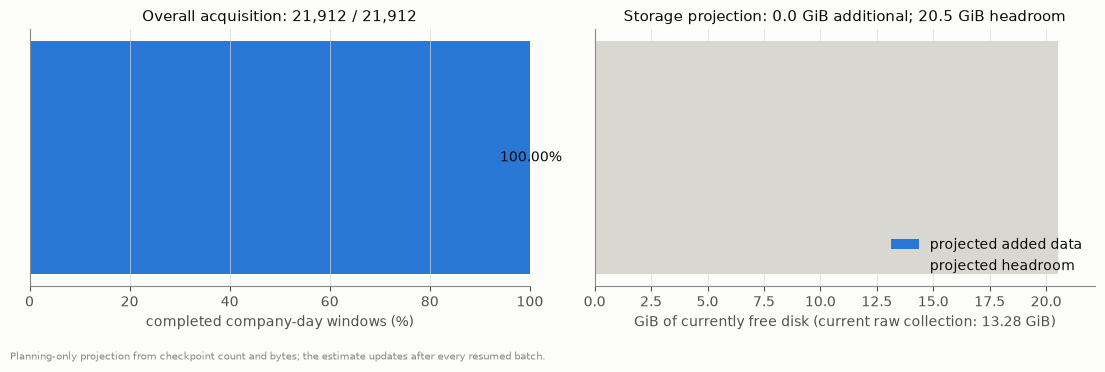

In [6]:
pct = float(progress['window_completion_pct'])
free_gib = float(projection['free_disk_gib'])
additional_gib = float(projection['projected_additional_storage_gib'])
headroom_gib = float(projection['projected_free_after_completion_gib'])

fig, (ax_windows, ax_storage) = plt.subplots(1, 2, figsize=(11, 3.5))

ax_windows.barh([0], [100.0], color=INK['grid'])
ax_windows.barh([0], [pct], color=CATEGORICAL[0])
ax_windows.set_xlim(0, 100)
ax_windows.set_yticks([])
ax_windows.set_xlabel('completed company-day windows (%)')
ax_windows.set_title(
    f"Overall acquisition: {int(progress['completed_windows']):,} / {int(progress['expected_windows']):,}"
)
ax_windows.text(min(pct + 1.2, 94), 0, f"{pct:.2f}%", va='center', color=INK['primary'])

if headroom_gib >= 0:
    ax_storage.barh([0], [additional_gib], color=CATEGORICAL[0], label='projected added data')
    ax_storage.barh(
        [0],
        [headroom_gib],
        left=[additional_gib],
        color=INK['grid'],
        label='projected headroom',
    )
else:
    ax_storage.barh([0], [free_gib], color=STATUS['critical'], alpha=0.35, label='free disk')
    ax_storage.barh([0], [additional_gib], color=STATUS['critical'], alpha=0.75, label='projected need')
ax_storage.set_xlim(0, max(free_gib, additional_gib, 1.0) * 1.08)
ax_storage.set_yticks([])
ax_storage.set_xlabel(
    f"GiB of currently free disk (current raw collection: {projection['current_raw_storage_gib']:.2f} GiB)"
)
ax_storage.set_title(
    f"Storage projection: {additional_gib:.1f} GiB additional; {headroom_gib:.1f} GiB headroom"
)
ax_storage.legend(loc='lower right')

annotate_source(
    fig,
    'Planning-only projection from checkpoint count and bytes; the estimate updates after every resumed batch.',
)
fig.tight_layout()
plt.show()

In [7]:
frontier_start = max(frontier_position - 2, 0)
frontier_stop = min(frontier_position + 5, len(date_progress))
frontier_view = date_progress.iloc[frontier_start:frontier_stop].copy()
frontier_view['date'] = frontier_view['date'].dt.date.astype(str)
display(
    frontier_view[
        ['window_index', 'date', 'completed_companies', 'expected_companies', 'complete_date', 'page_requests', 'checkpoint_mib']
    ].round({'checkpoint_mib': 2})
)

storage_status = (
    'RED_FLAG: projected completion exceeds currently free disk'
    if projection['projected_free_after_completion_gib'] < 0
    else (
        'WARNING: projected headroom is below 10 GiB'
        if projection['projected_free_after_completion_gib'] < 10
        else 'adequate under the current planning estimate'
    )
)
frontier_companies_completed = (
    None
    if pd.isna(progress['frontier_companies_completed'])
    else int(progress['frontier_companies_completed'])
)
operational_decision = {
    'complete_33_company_dates': int(progress['complete_dates']),
    'contiguous_complete_prefix_dates': int(progress['complete_date_prefix']),
    'frontier_date': progress['frontier_date'],
    'frontier_companies_completed': frontier_companies_completed,
    'estimated_remaining_full_quota_days': int(projection['estimated_remaining_quota_days']),
    'storage_status': storage_status,
    'score_status_loaded': True,
    'prices_or_returns_loaded': False,
}
assert operational_decision['score_status_loaded'] is True
assert operational_decision['prices_or_returns_loaded'] is False
operational_decision

,window_index,date,completed_companies,expected_companies,complete_date,page_requests,checkpoint_mib
662,663,2025-10-24,33,33,True,99,29.03
663,664,2025-10-25,33,33,True,74,13.97


{'complete_33_company_dates': 664,
 'contiguous_complete_prefix_dates': 664,
 'frontier_date': None,
 'frontier_companies_completed': None,
 'estimated_remaining_full_quota_days': 0,
 'storage_status': 'adequate under the current planning estimate',
 'score_status_loaded': True,
 'prices_or_returns_loaded': False}

## Gemma measurement-drift gate

The strategy's event clock depends on Gemma returning an exact signed score of +1 or -1. Hosted model names and provider pins do not cryptographically pin weights, so a fresh historical score population is not comparable until the endpoint behaviour is rechecked.

The frozen sample is return-blind: all 774 exact endpoints in the completed 888,155-headline reference file, plus 1,000 non-endpoints chosen by deterministic hash order. No headline or score is selected using a stock return. Drift failure stops the arm; it does not license a new threshold.

In [8]:
spec = json.loads(SPEC_PATH.read_text(encoding='utf-8'))
drift = spec['gemma_model_drift_gate']
drift_design = pd.DataFrame(
    [
        {'metric': 'continuous Spearman', 'pass rule': f">= {drift['continuous_spearman_minimum']:.2f}"},
        {'metric': 'mean absolute score difference', 'pass rule': f"<= {drift['continuous_mean_absolute_difference_maximum']:.2f}"},
        {'metric': 'direction agreement', 'pass rule': f">= {drift['direction_agreement_minimum']:.2%}"},
        {'metric': 'same exact endpoint and direction retained', 'pass rule': f">= {drift['endpoint_same_direction_retention_minimum']:.2%}"},
        {'metric': 'endpoint reversed to opposite direction', 'pass rule': f"<= {drift['endpoint_opposite_direction_count_maximum']} rows"},
        {'metric': 'non-endpoint becomes exact endpoint', 'pass rule': f"<= {drift['nonendpoint_to_endpoint_rate_maximum']:.2%}"},
    ]
)
display(drift_design)
{'endpoint_census': 774, 'nonendpoint_controls': 1000, 'paid_drift_scoring_authorised': False}

,metric,pass rule
0,continuous Spearman,>= 0.95
1,mean absolute score difference,<= 0.10
2,direction agreement,>= 90.00%
3,same exact endpoint and direction retained,>= 80.00%
4,endpoint reversed to opposite direction,<= 0 rows
5,non-endpoint becomes exact endpoint,<= 5.00%


{'endpoint_census': 774,
 'nonendpoint_controls': 1000,
 'paid_drift_scoring_authorised': False}

## Predeclared one-shot methodology after the gates

The primary replay inherits the exact strongest-event collision rule, Gemma endpoint dates/counts, FinBERT within-session ranking, equal leg weights, 25% name cap, gross limit 1, dollar neutrality, cash for unused capacity, next-open holding interval, drift-aware turnover, final liquidation, and 10 bps per traded side. It will report gross and net Sharpe, return, turnover, drawdown, break-even cost, block-bootstrap cash inference, HAC market-plus-sector alpha, chronological halves, and rebuilt company/sector exclusions.

Two non-promoting mechanism tests form one BH family: circular shifts of Gemma's full date/count schedule, and same-session matched-count random-name assignments. These distinguish event timing from FinBERT name selection but cannot rescue a failed primary gate.

In [9]:
storage_headroom_gib = float(projection['projected_free_after_completion_gib'])
decision = {
    'collection_status': progress['status'],
    'collection_gate_pass': bool(collection_audit.collection_gate_pass),
    'complete_date_prefix': int(progress['complete_date_prefix']),
    'frontier_date': progress['frontier_date'],
    'estimated_remaining_full_quota_days': int(projection['estimated_remaining_quota_days']),
    'projected_storage_headroom_gib': storage_headroom_gib,
    'drift_scoring_authorised': False,
    'prices_or_returns_loaded': False,
    'next_action': (
        'prepare frozen drift sample and request paid-scoring approval'
        if collection_audit.collection_gate_pass
        else (
            'free or relocate storage, then continue the immutable date-major headline collection'
            if storage_headroom_gib < 10
            else 'continue the immutable date-major headline collection at the next quota reset'
        )
    ),
}
assert decision['prices_or_returns_loaded'] is False
decision

{'collection_status': 'completed',
 'collection_gate_pass': True,
 'complete_date_prefix': 664,
 'frontier_date': None,
 'estimated_remaining_full_quota_days': 0,
 'projected_storage_headroom_gib': 20.52218246459961,
 'drift_scoring_authorised': False,
 'prices_or_returns_loaded': False,
 'next_action': 'prepare frozen drift sample and request paid-scoring approval'}